# Disque 100 latent typologies with DAMICORE

Each report is one DAMICORE object. PostgreSQL only supplies the data; DAMICORE is the only clustering method. The default deterministic cohort has 500 reports because pairwise distances do not scale to all 371,117 reports at once.

In [11]:
%pip install -q "damicore==0.2.0" "psycopg[binary]>=3.2,<4" matplotlib biopython

Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
from damicore import estimate, run
from psycopg import sql

DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql:///disque100")
SAMPLE_SIZE = 500
SAMPLE_SEED = "42"
START_DATE = "2026-01-01"
END_DATE = "2026-07-01"

RUN_NAME = "disque100-damicore-20260821-02"
OUTPUT_DIR = Path("output")
CORPUS_DIR = OUTPUT_DIR / f"{RUN_NAME}-corpus"
RUN_DIR = OUTPUT_DIR / f"{RUN_NAME}-run"
MEMBERSHIP_FILE = OUTPUT_DIR / f"{RUN_NAME}-membership.csv"
TREE_PDF = OUTPUT_DIR / f"{RUN_NAME}-tree.pdf"
FOCUS_SOURCE_HASH = None  # Use None for the first report or paste one source_hash here.

In [13]:
# Reuse the exact existing corpus or build one text file per report.
if CORPUS_DIR.exists():
    entries = list(CORPUS_DIR.iterdir())
    valid_files = [
        path for path in entries
        if path.is_file() and path.suffix == ".txt" and path.stat().st_size > 0
    ]
    if len(entries) != SAMPLE_SIZE or len(valid_files) != SAMPLE_SIZE:
        raise RuntimeError(f"Existing corpus is incomplete or unexpected: {CORPUS_DIR}")
    print(f"Reusing {len(valid_files)} report objects from {CORPUS_DIR}")
else:
    CORPUS_DIR.mkdir(parents=True)
    query = sql.SQL("""
        WITH cohort AS (
            SELECT source_hash
            FROM {table}
            WHERE registered_at >= %s AND registered_at < %s
            GROUP BY source_hash
            ORDER BY md5(source_hash || %s)
            LIMIT %s
        )
        SELECT
            reports.source_hash,
            jsonb_agg(
                jsonb_strip_nulls(
                    to_jsonb(reports) - ARRAY['id', 'source_hash', 'registered_at']::text[]
                )
                ORDER BY reports.id
            )::text AS report_text
        FROM {table} AS reports
        JOIN cohort USING (source_hash)
        GROUP BY reports.source_hash
        ORDER BY reports.source_hash
    """).format(table=sql.Identifier("public", "disque100_reports"))

    with psycopg.connect(DATABASE_URL) as connection:
        with connection.cursor() as cursor:
            cursor.execute(query, (START_DATE, END_DATE, SAMPLE_SEED, SAMPLE_SIZE))
            reports = cursor.fetchall()

    if len(reports) != SAMPLE_SIZE:
        raise RuntimeError(f"Expected {SAMPLE_SIZE} reports, found {len(reports)}.")

    for source_hash, report_text in reports:
        (CORPUS_DIR / f"{source_hash}.txt").write_text(report_text, encoding="utf-8")

    print(f"Created {len(reports)} report objects in {CORPUS_DIR}")

Reusing 500 report objects from output/disque100-damicore-20260821-02-corpus


In [14]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())

if not preview.within_limits:
    raise RuntimeError(f"DAMICORE limits exceeded: {preview.violations}")

{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-corpus/00515441524105EA7CD870DC5415F64B650A09C43486D93AE5560C056BCCA129.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-corpus/005C36B5855B7FB8845FD5A8712E2222933969412F9D5346CBAEDCB9583E7ACC.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-corpus/00957521478D60F72D40F2D607D9AD695D6F7B08EC2F83D643AAC3A3701E0577.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-corpus/01D6B910BEB30D4CF34FD5666EDC72E976A5E146E8A2D05ABFB5AB9D9A8DB916.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-corpus/0207846F8E2AADFDFD291A4645DD9A5378CABCAFD88114A70CB3B941878153E1.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/output/disque100-damicore-20260821-02-

In [15]:
# A compatible completed run is reused automatically by DAMICORE.
result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)

try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    clusters = dict(result.clusters)
    tree_newick = result.tree_newick
finally:
    result.close()

membership["source_hash"] = membership["label"].str.removesuffix(".txt")
membership.to_csv(MEMBERSHIP_FILE, index=False)
display(membership.head(20))
print(f"Membership saved to {MEMBERSHIP_FILE}")

,object_id,label,cluster,source_hash
0,file_000001,00515441524105EA7CD870DC5415F64B650A09C43486D9...,0,00515441524105EA7CD870DC5415F64B650A09C43486D9...
1,file_000002,005C36B5855B7FB8845FD5A8712E2222933969412F9D53...,1,005C36B5855B7FB8845FD5A8712E2222933969412F9D53...
2,file_000003,00957521478D60F72D40F2D607D9AD695D6F7B08EC2F83...,2,00957521478D60F72D40F2D607D9AD695D6F7B08EC2F83...
3,file_000004,01D6B910BEB30D4CF34FD5666EDC72E976A5E146E8A2D0...,3,01D6B910BEB30D4CF34FD5666EDC72E976A5E146E8A2D0...
4,file_000005,0207846F8E2AADFDFD291A4645DD9A5378CABCAFD88114...,4,0207846F8E2AADFDFD291A4645DD9A5378CABCAFD88114...
5,file_000006,02AFBA943BBDD6A0EED1262731E98CA14401077DE96ECE...,5,02AFBA943BBDD6A0EED1262731E98CA14401077DE96ECE...
6,file_000007,02ED1076259016319370688F775649761A25A90D9E7213...,6,02ED1076259016319370688F775649761A25A90D9E7213...
7,file_000008,03ADD53FA69DDC15AA732069F72B6AEB540EFBFED2143D...,7,03ADD53FA69DDC15AA732069F72B6AEB540EFBFED2143D...
8,file_000009,047F9D17C5CA4D35C8B8AA3E7F83B2CD6EC012BAD13456...,8,047F9D17C5CA4D35C8B8AA3E7F83B2CD6EC012BAD13456...
9,file_000010,05B14EB34E097B4EB3446CE1DC6F3169C7BE482108F5DA...,5,05B14EB34E097B4EB3446CE1DC6F3169C7BE482108F5DA...


Membership saved to output/disque100-damicore-20260821-02-membership.csv


## Visualizations

The charts below describe the clusters produced by DAMICORE. They do not apply another clustering or dimensionality-reduction algorithm.

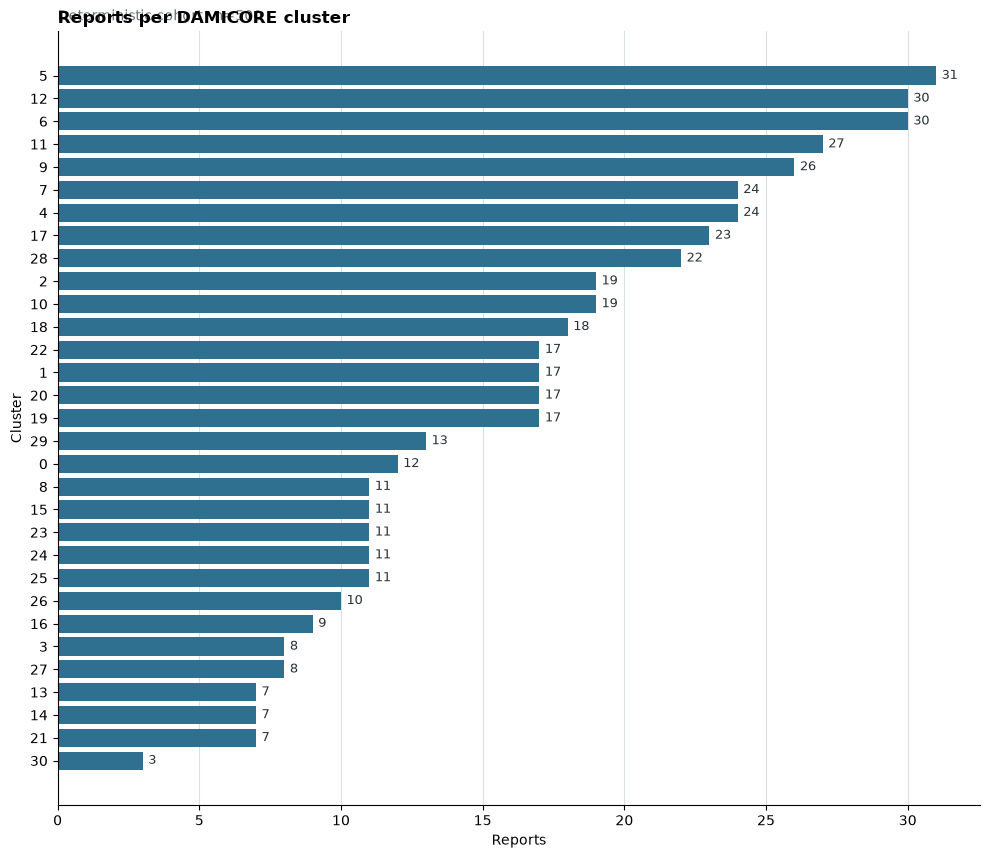

In [16]:
# Cluster size makes the membership result easier to scan.
cluster_summary = (
    membership.groupby("cluster")
    .size()
    .rename("report_count")
    .reset_index()
    .sort_values("report_count")
)

figure, axis = plt.subplots(figsize=(10, max(6, len(cluster_summary) * 0.28)))
bars = axis.barh(
    cluster_summary["cluster"].astype(str),
    cluster_summary["report_count"],
    color="#2F6F8F",
)
axis.bar_label(bars, padding=4, color="#263238", fontsize=9)
axis.set_title("Reports per DAMICORE cluster", loc="left", weight="bold")
axis.text(
    0, 1.01, f"Deterministic cohort · n={len(membership):,}",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom"
)
axis.set_xlabel("Reports")
axis.set_ylabel("Cluster")
axis.set_xlim(left=0)
axis.grid(axis="x", color="#D9E0E3", linewidth=0.8)
axis.set_axisbelow(True)
axis.spines[["top", "right"]].set_visible(False)
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

In [17]:
# Lower NCD means that two report objects are more similar.
focus_source_hash = FOCUS_SOURCE_HASH or membership.iloc[0]["source_hash"]
focus_label = f"{focus_source_hash}.txt"

if focus_label not in distance_matrix.index:
    raise KeyError(f"Report is not part of this cohort: {focus_source_hash}")

nearest_neighbors = (
    distance_matrix.loc[focus_label]
    .drop(focus_label)
    .nsmallest(5)
    .rename("ncd_distance")
    .rename_axis("label")
    .reset_index()
    .merge(membership[["label", "source_hash", "cluster"]], on="label")
    [["source_hash", "cluster", "ncd_distance"]]
)

nearest_neighbors["ncd_distance"] = nearest_neighbors["ncd_distance"].round(4)
print(f"Five nearest reports to {focus_source_hash}:")
display(nearest_neighbors)

Five nearest reports to 00515441524105EA7CD870DC5415F64B650A09C43486D93AE5560C056BCCA129:


,source_hash,cluster,ncd_distance
0,9DBC29E298B0EF7FA047CA7396875871D0BA346B7A1BB3...,0,0.1843
1,C715DE2EF0771C738AE0A7FB2FE0E424A98AC44A1B56A7...,0,0.2345
2,0E1DB19454A22009B0F43461506A6B94D35B291752F31D...,18,0.2395
3,CA5401F1D06A22520E5B2567C1F1A866EBC463B39E23EF...,0,0.2424
4,EEEC20DFE0701AE6A3252243264AC1ED63C506B74E7229...,0,0.2540


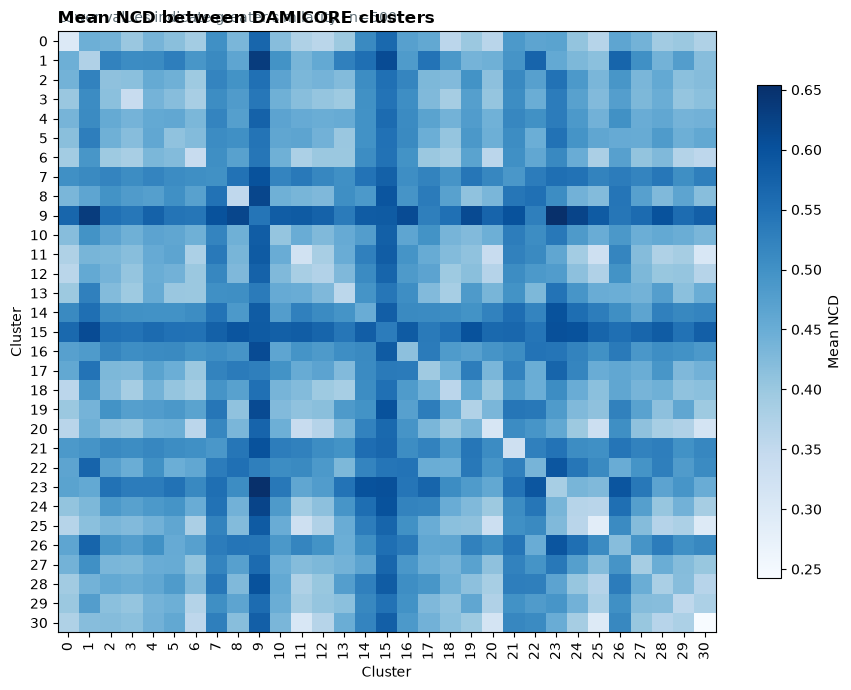

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.297,0.446,0.439,0.401,0.436,0.417,0.390,0.502,0.433,0.568,...,0.485,0.465,0.468,0.407,0.365,0.463,0.439,0.391,0.399,0.374
1,0.446,0.373,0.523,0.508,0.510,0.529,0.490,0.512,0.462,0.633,...,0.493,0.571,0.457,0.429,0.414,0.570,0.502,0.440,0.478,0.420
2,0.439,0.523,0.411,0.414,0.456,0.444,0.395,0.520,0.496,0.551,...,0.513,0.473,0.549,0.485,0.432,0.491,0.433,0.458,0.415,0.421
3,0.401,0.508,0.414,0.339,0.437,0.419,0.383,0.507,0.480,0.540,...,0.506,0.448,0.533,0.471,0.425,0.476,0.430,0.449,0.405,0.416
4,0.436,0.510,0.456,0.437,0.458,0.460,0.432,0.519,0.474,0.574,...,0.516,0.500,0.533,0.486,0.441,0.499,0.450,0.461,0.438,0.440
5,0.417,0.529,0.444,0.419,0.460,0.411,0.424,0.508,0.501,0.546,...,0.507,0.448,0.549,0.496,0.462,0.453,0.451,0.482,0.445,0.459
6,0.390,0.490,0.395,0.383,0.432,0.424,0.340,0.504,0.472,0.542,...,0.502,0.459,0.514,0.450,0.379,0.473,0.407,0.426,0.368,0.356
7,0.502,0.512,0.520,0.507,0.519,0.508,0.504,0.500,0.549,0.600,...,0.489,0.532,0.553,0.549,0.521,0.532,0.519,0.540,0.504,0.528
8,0.433,0.462,0.496,0.480,0.474,0.501,0.472,0.549,0.352,0.617,...,0.541,0.551,0.507,0.441,0.423,0.543,0.474,0.427,0.465,0.418
9,0.568,0.633,0.551,0.540,0.574,0.546,0.542,0.600,0.617,0.544,...,0.600,0.528,0.654,0.620,0.585,0.542,0.559,0.600,0.558,0.579


In [22]:
# Aggregate the report-level matrix into mean distances between DAMICORE clusters.
cluster_ids = sorted(membership["cluster"].unique())
cluster_distance = pd.DataFrame(index=cluster_ids, columns=cluster_ids, dtype=float)

for row_cluster in cluster_ids:
    row_labels = membership.loc[membership["cluster"] == row_cluster, "label"].tolist()
    for column_cluster in cluster_ids:
        column_labels = membership.loc[
            membership["cluster"] == column_cluster, "label"
        ].tolist()
        block = distance_matrix.loc[row_labels, column_labels].to_numpy()
        if row_cluster == column_cluster:
            values = block[np.triu_indices_from(block, k=1)]
        else:
            values = block.ravel()
        cluster_distance.loc[row_cluster, column_cluster] = (
            values.mean() if values.size else np.nan
        )

figure, axis = plt.subplots(figsize=(9, 7))
image = axis.imshow(cluster_distance, cmap="Blues", aspect="auto")
axis.set_title("Mean NCD between DAMICORE clusters", loc="left", weight="bold")
axis.text(
    0, 1.01, f"Lower values indicate greater similarity · n={len(membership):,}",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom"
)
axis.set_xlabel("Cluster")
axis.set_ylabel("Cluster")
axis.set_xticks(range(len(cluster_ids)), labels=cluster_ids, rotation=90)
axis.set_yticks(range(len(cluster_ids)), labels=cluster_ids)
colorbar = figure.colorbar(image, ax=axis, shrink=0.82)
colorbar.set_label("Mean NCD")
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

display(cluster_distance.round(3))

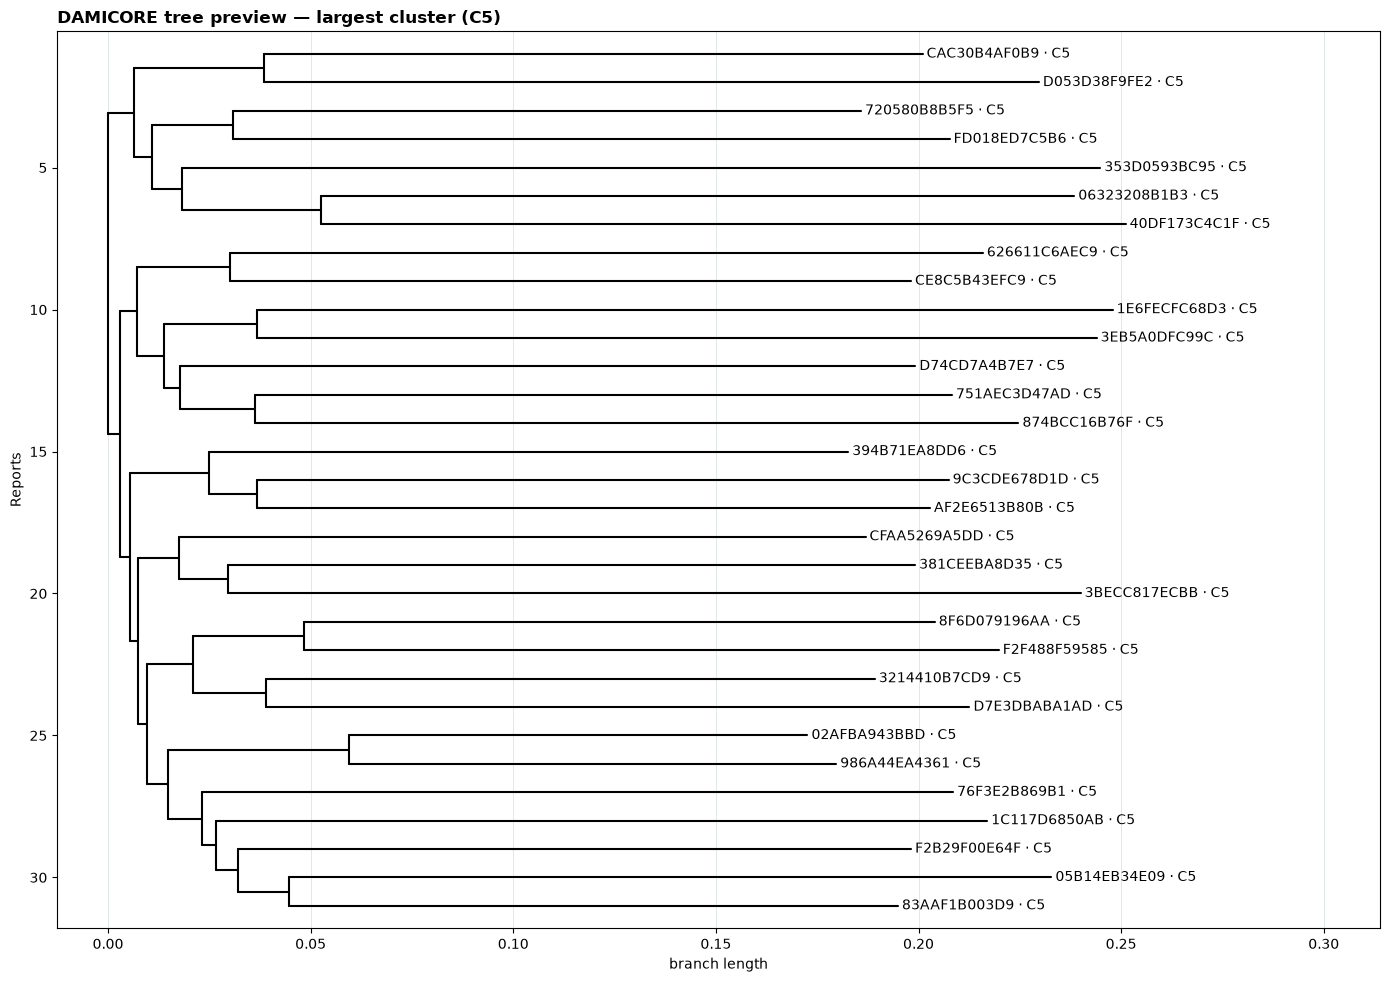

Printable tree saved to output/disque100-damicore-20260821-02-tree.pdf
Newick artifact: output/disque100-damicore-20260821-02-run/tree.nwk


In [20]:
# Preview the largest cluster and export the full DAMICORE tree for printing.
import html
from copy import deepcopy
from io import StringIO

from Bio import Phylo
from IPython.display import HTML

tree = Phylo.read(StringIO(tree_newick), "newick")
object_labels = {
    row.object_id: f"{row.source_hash[:12]} · C{row.cluster}"
    for row in membership.itertuples()
}

largest_cluster = int(cluster_summary.iloc[-1]["cluster"])
largest_cluster_objects = set(
    membership.loc[membership["cluster"] == largest_cluster, "object_id"]
)
preview_tree = deepcopy(tree)
for terminal in list(preview_tree.get_terminals()):
    if terminal.name not in largest_cluster_objects:
        preview_tree.prune(terminal)
for terminal in preview_tree.get_terminals():
    terminal.name = object_labels[terminal.name]

figure, axis = plt.subplots(
    figsize=(14, max(8, len(largest_cluster_objects) * 0.32))
)
Phylo.draw(
    preview_tree,
    axes=axis,
    do_show=False,
    show_confidence=False,
    label_func=lambda node: node.name if node.is_terminal() else None,
)
axis.set_title(
    f"DAMICORE tree preview — largest cluster (C{largest_cluster})",
    loc="left", weight="bold"
)
axis.set_ylabel("Reports")
axis.grid(axis="x", color="#E2E7E9", linewidth=0.7)
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

printable_tree = deepcopy(tree)
for terminal in printable_tree.get_terminals():
    terminal.name = object_labels[terminal.name]

pdf_figure, pdf_axis = plt.subplots(figsize=(18, max(60, len(membership) * 0.16)))
Phylo.draw(
    printable_tree,
    axes=pdf_axis,
    do_show=False,
    show_confidence=False,
    label_func=lambda node: node.name if node.is_terminal() else None,
)
pdf_axis.set_title("Full DAMICORE tree — Disque 100 cohort", loc="left", weight="bold")
pdf_figure.patch.set_facecolor("white")
pdf_axis.set_facecolor("white")
pdf_figure.savefig(TREE_PDF, bbox_inches="tight")
plt.close(pdf_figure)

escaped_newick = html.escape(tree_newick)
display(HTML(
    f"""
    <details>
      <summary>Show full Newick tree</summary>
      <pre style="max-height:24rem;overflow:auto;white-space:pre-wrap">{escaped_newick}</pre>
    </details>
    """
))
print(f"Printable tree saved to {TREE_PDF}")
print(f"Newick artifact: {RUN_DIR / 'tree.nwk'}")